# RQ1 — Structural Nature of Agent-Authored Merge Conflicts

> *In merge commits that occur inside agent-authored PRs, what are the
> distributions of (i) the number of conflicting chunks per failed merge,
> (ii) the size in lines of code of `v1`, (iii) the size in lines of
> code of `v2`, and (iv) the size in lines of code of the resolution?*
> — PLAN.md §3 (RQ1)

This notebook reproduces the four structural distributions of Ghiotto
et al. (TSE 2020, figures A1, A2) over the agent universe, plus the new
`resolution_loc` metric (PLAN.md §5.5). Every figure is emitted both
globally and stratified along the three cross-cutting axes: **agent**,
**language** (top-N), and **pr_task_type**.

All figures are saved to `analysis/figures/` as `.pdf` + `.png`.


In [1]:
# Ensure the project root is on sys.path so ``analysis.common`` imports
# cleanly whether the kernel was launched from the repo root or from
# inside analysis/.
import sys
from pathlib import Path

_here = Path.cwd()
for candidate in [_here, *_here.parents]:
    if (candidate / "analysis" / "common.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import (
    load_tables,
    build_chunk_frame, build_merge_frame, build_pr_frame,
    setup_style, save_fig,
    stratify, stratum_order,
    descriptive_table, strategy_distribution,
    STRATEGY_ORDER, STRATEGY_PALETTE,
    RESOLVER_ORDER, RESOLVER_PALETTE,
    PR_OUTCOME_ORDER, PR_OUTCOME_PALETTE,
    TOP_N_LANGUAGES,
)

setup_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 1. Load pipeline outputs

In [2]:
tables = load_tables()
print("Universe rows (pr_id, sha):", len(tables.universe))
print("Internal merges:          ", len(tables.internal_merges))
print("Classified chunks:        ", len(tables.classified_chunks))
print("Resolved chunks:          ", len(tables.resolved_chunks))
print("Extraction errors:        ", len(tables.extraction_errors))


Universe rows (pr_id, sha): 0
Internal merges:           81
Classified chunks:         131
Resolved chunks:           131
Extraction errors:         0


## 2. Build analysis frames

In [3]:
chunks  = build_chunk_frame(tables)
merges  = build_merge_frame(tables)

# Only failed merges carry chunk-level distributions.
failed_merges = merges[merges["has_conflict"]].copy()

print(f"Chunks (classified):     {len(chunks):>10,}")
print(f"Internal merges:         {len(merges):>10,}")
print(f"Internal merges w/ conflict: {len(failed_merges):>6,}  "
      f"({len(failed_merges)/max(len(merges),1):.1%})")
chunks.head()


Chunks (classified):            131
Internal merges:                 81
Internal merges w/ conflict:     11  (13.6%)


,pr_id,merge_sha,file_path,chunk_index,v1,base,v2,v1_loc,v2_loc,base_loc,resolution,localized_ok,resolution_loc,strategy,strategy_raw,resolver_type
0,3138027382,5a19f62dd10bcbc0b62ceded3f9b41b06310657c,lib/roast.rb,0,"desc ""validate [WORKFLOW_CONFIGURATION_FIL...",,"desc ""sessions"", ""List stored workflow ses...",6,77,0,"desc ""validate [WORKFLOW_CONFIGURATION_FIL...",True,83,CC,ConcatV1V2,human
1,3086930190,a9d5855f013df36693a86fd372ac5e3cf0f80a4f,kura/cluster.py,0,{% for item in positive_examples %}{{ item.emb...,{% for item in positive_examples %}{{ item.sum...,{% for item in positive_examples %}{{ item.emb...,1,1,1,{% for item in positive_examples %}{{ item.emb...,True,1,V1,V1,agent-assisted
2,3086930190,a9d5855f013df36693a86fd372ac5e3cf0f80a4f,kura/cluster.py,1,{% for item in contrastive_examples %}{{ item....,{% for item in contrastive_examples %}{{ item....,{% for item in contrastive_examples %}{{ item....,1,1,1,{% for item in contrastive_examples %}{{ item....,True,1,V1,V1,agent-assisted
3,3086930190,a9d5855f013df36693a86fd372ac5e3cf0f80a4f,kura/cluster.py,2,self.embedding_model.embed(tex...,self.embedding_model.embed(tex...,self.embedding_model.embed(tex...,1,1,1,<<<<<<< HEAD\n self.embedding_m...,True,5,Imprecise,Postponed,agent-assisted
4,3086930190,a9d5855f013df36693a86fd372ac5e3cf0f80a4f,kura/types/summarisation.py,0,def embeddable_text(self) -> str:\n ...,,"def embeded_text(self):\n return f""...",2,24,0,def embeddable_text(self) -> str:\n ...,True,6,NC,New code,agent-assisted


## 3. Descriptive statistics (Ghiotto-style summary)

In [4]:
summary_rows = []
if not failed_merges.empty:
    summary_rows.append(
        descriptive_table(failed_merges["n_chunks"]).rename("chunks_per_merge"))
for col in ("v1_loc", "v2_loc", "resolution_loc"):
    if col in chunks.columns:
        summary_rows.append(descriptive_table(chunks[col]).rename(col))
summary_df = pd.concat(summary_rows, axis=1) if summary_rows else pd.DataFrame()
summary_df.round(2)


,chunks_per_merge,v1_loc,v2_loc,resolution_loc
n,11.00,131.00,131.00,131.00
mean,11.91,9.08,9.19,9.27
std,23.69,19.13,20.26,23.08
min,1.00,0.00,0.00,0.00
p25,3.00,2.00,1.00,1.00
median,3.00,3.00,1.00,3.00
p75,8.00,3.00,3.00,3.00
p90,16.00,22.00,29.00,18.00
p95,49.00,36.50,48.00,78.00
p99,75.40,94.00,94.00,96.00


## 4. Figure 1 — Chunks per failed merge (global)

Histogram with log-scaled y axis plus an empirical CDF overlay. This
corresponds to Ghiotto et al.'s A1.


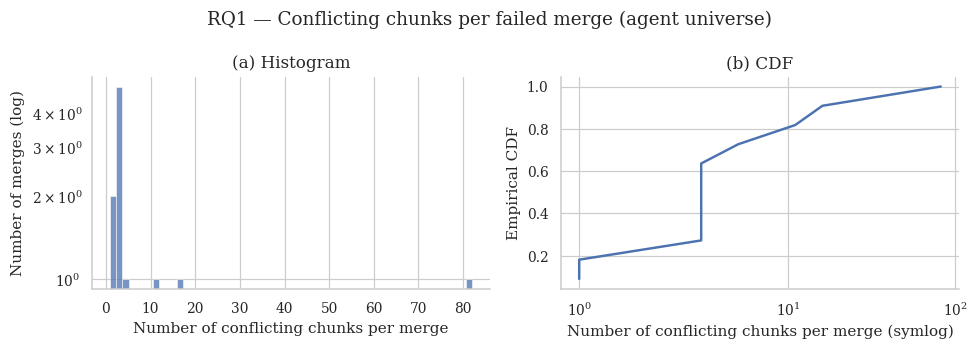

In [5]:
if not failed_merges.empty:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

    sns.histplot(
        failed_merges["n_chunks"],
        bins=min(60, int(failed_merges["n_chunks"].max()) + 1),
        ax=axes[0], color=STRATEGY_PALETTE["V1"],
    )
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Number of conflicting chunks per merge")
    axes[0].set_ylabel("Number of merges (log)")
    axes[0].set_title("(a) Histogram")

    sorted_n = np.sort(failed_merges["n_chunks"].values)
    cdf = np.arange(1, len(sorted_n) + 1) / len(sorted_n)
    axes[1].plot(sorted_n, cdf, color=STRATEGY_PALETTE["V1"], lw=1.6)
    axes[1].set_xscale("symlog")
    axes[1].set_xlabel("Number of conflicting chunks per merge (symlog)")
    axes[1].set_ylabel("Empirical CDF")
    axes[1].set_title("(b) CDF")

    fig.suptitle("RQ1 — Conflicting chunks per failed merge (agent universe)")
    save_fig(fig, "rq1_chunks_per_merge_global")
    plt.show()
else:
    print("No failed merges available yet -- run the pipeline first.")


## 5. Figure 2 — Chunk-level LOC distributions (global)

One panel per metric (`v1_loc`, `v2_loc`, `resolution_loc`). Log-scaled
y axis so the long tail remains visible. Ghiotto et al. A2 only reports
`v1` / `v2`; our `resolution_loc` adds the new third distribution.


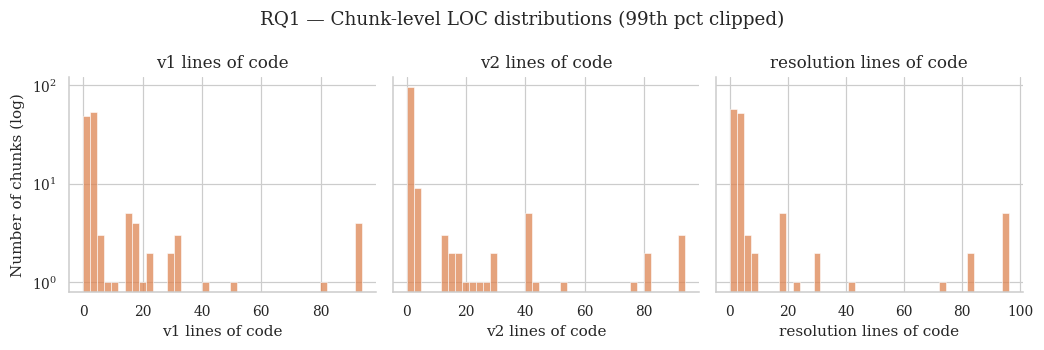

In [6]:
metrics = [("v1_loc", "v1 lines of code"),
           ("v2_loc", "v2 lines of code"),
           ("resolution_loc", "resolution lines of code")]
metrics = [(c, lab) for c, lab in metrics if c in chunks.columns]

if chunks.empty or not metrics:
    print("Chunk-level data missing -- run the pipeline first.")
else:
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.2 * len(metrics), 3.2), sharey=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, (col, label) in zip(axes, metrics):
        data = chunks[col].clip(upper=chunks[col].quantile(0.99))
        sns.histplot(data, bins=40, ax=ax, color=STRATEGY_PALETTE["V2"])
        ax.set_yscale("log")
        ax.set_xlabel(label)
        ax.set_title(label)
    axes[0].set_ylabel("Number of chunks (log)")
    fig.suptitle("RQ1 — Chunk-level LOC distributions (99th pct clipped)")
    save_fig(fig, "rq1_loc_distributions_global")
    plt.show()


## 6. Figure 3 — Chunks per merge by agent

Per-agent boxplot on the log scale. Reveals whether, say, Copilot
produces merges with systematically more or fewer conflict chunks
than Codex.


In [7]:
if not failed_merges.empty and "agent" in failed_merges.columns:
    agent_order = stratum_order(failed_merges, "agent")
    fig, ax = plt.subplots(figsize=(max(5, 0.9 * len(agent_order) + 2), 3.4))
    sns.boxplot(
        data=failed_merges, x="agent", y="n_chunks",
        order=agent_order, showfliers=False, ax=ax, color=STRATEGY_PALETTE["V1"],
    )
    ax.set_yscale("symlog")
    ax.set_xlabel("Agent")
    ax.set_ylabel("Chunks per merge (symlog)")
    ax.set_title("RQ1 — Chunks per merge, by agent")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    save_fig(fig, "rq1_chunks_per_merge_by_agent")
    plt.show()
else:
    print("Need failed merges with an 'agent' column.")


Need failed merges with an 'agent' column.


## 7. Figure 4 — Chunk LOC by agent (faceted)

In [8]:
if not chunks.empty and "agent" in chunks.columns and metrics:
    long_df = chunks.melt(
        id_vars=["agent"],
        value_vars=[c for c, _ in metrics],
        var_name="metric", value_name="loc",
    ).dropna()

    agent_order = stratum_order(chunks, "agent")
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.6 * len(metrics), 3.4), sharey=True)
    if len(metrics) == 1:
        axes = [axes]
    for ax, (col, label) in zip(axes, metrics):
        d = long_df[long_df["metric"] == col]
        sns.boxplot(data=d, x="agent", y="loc", order=agent_order,
                    showfliers=False, ax=ax, color=STRATEGY_PALETTE["V2"])
        ax.set_yscale("symlog")
        ax.set_title(label)
        ax.set_xlabel("")
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    axes[0].set_ylabel("LOC (symlog)")
    fig.suptitle("RQ1 — Chunk-level LOC by agent")
    save_fig(fig, "rq1_loc_by_agent")
    plt.show()


## 8. Figure 5 — Chunks per merge by language (top-N)

In [9]:
if not failed_merges.empty and "language_top" in failed_merges.columns:
    lang_order = stratum_order(failed_merges, "language")
    fig, ax = plt.subplots(figsize=(max(5, 0.7 * len(lang_order) + 2), 3.4))
    sns.boxplot(
        data=failed_merges, x="language_top", y="n_chunks",
        order=lang_order, showfliers=False, ax=ax, color=STRATEGY_PALETTE["CC"],
    )
    ax.set_yscale("symlog")
    ax.set_xlabel("Language (top)")
    ax.set_ylabel("Chunks per merge (symlog)")
    ax.set_title("RQ1 — Chunks per merge, by language")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    save_fig(fig, "rq1_chunks_per_merge_by_language")
    plt.show()


## 9. Figure 6 — Chunks per merge by PR task type

In [10]:
if not failed_merges.empty and "pr_task_type" in failed_merges.columns:
    subset = failed_merges.dropna(subset=["pr_task_type"]).copy()
    if subset.empty:
        print("pr_task_type is only populated under --pop-only (AIDev's enriched tier).")
    else:
        task_order = stratum_order(subset, "pr_task_type")
        fig, ax = plt.subplots(figsize=(max(5, 0.7 * len(task_order) + 2), 3.4))
        sns.boxplot(
            data=subset, x="pr_task_type", y="n_chunks",
            order=task_order, showfliers=False, ax=ax, color=STRATEGY_PALETTE["CB"],
        )
        ax.set_yscale("symlog")
        ax.set_xlabel("PR task type")
        ax.set_ylabel("Chunks per merge (symlog)")
        ax.set_title("RQ1 — Chunks per merge, by PR task type")
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
        save_fig(fig, "rq1_chunks_per_merge_by_task_type")
        plt.show()


## 10. Per-stratum descriptive tables

In [11]:
def stratum_descriptive(df, group_col, numeric_col):
    if df.empty or group_col not in df.columns:
        return pd.DataFrame()
    return (
        df.groupby(group_col)[numeric_col]
          .apply(descriptive_table)
          .unstack()
          .round(2)
          .sort_values("n", ascending=False)
    )

tables_out = {}
if not failed_merges.empty:
    tables_out["chunks_per_merge_by_agent"] = stratum_descriptive(
        failed_merges, "agent", "n_chunks")
    tables_out["chunks_per_merge_by_language"] = stratum_descriptive(
        failed_merges, "language_top", "n_chunks")
for col in ("v1_loc", "v2_loc", "resolution_loc"):
    if col in chunks.columns:
        tables_out[f"{col}_by_agent"] = stratum_descriptive(
            chunks, "agent", col)

for name, t in tables_out.items():
    print(f"\n=== {name} ===")
    print(t.to_string() if not t.empty else "(no rows)")



=== chunks_per_merge_by_agent ===
(no rows)

=== chunks_per_merge_by_language ===
(no rows)

=== v1_loc_by_agent ===
(no rows)

=== v2_loc_by_agent ===
(no rows)

=== resolution_loc_by_agent ===
(no rows)


---
### Outputs summary

This notebook writes (one PDF + one PNG each) to `analysis/figures/`:

| File stem                              | Paper role |
|----------------------------------------|------------|
| `rq1_chunks_per_merge_global`          | Figure: overall A1 replication |
| `rq1_loc_distributions_global`         | Figure: overall A2 replication + resolution_loc |
| `rq1_chunks_per_merge_by_agent`        | Stratified by agent |
| `rq1_loc_by_agent`                     | Stratified by agent (LOC panels) |
| `rq1_chunks_per_merge_by_language`     | Stratified by language (top-N) |
| `rq1_chunks_per_merge_by_task_type`    | Stratified by `pr_task_type` (AIDev-pop only) |

Numerical tables are printed above for inclusion in the paper.
